# Customer Churn Prediction — Exploratory Data Analysis

**Dataset:** IBM Telco Customer Churn  
**Source:** https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv  
**Data Type:** REAL (publicly sourced, not synthetic)  

This notebook performs data cleaning, exploratory data analysis, model training, and evaluation
for predicting customer churn in a telecommunications company.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})

# Ensure figures directory exists
FIGURES_DIR = os.path.join('..', 'reports', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load the Raw Dataset

We load the original Telco Customer Churn dataset and inspect its structure.

In [2]:
df = pd.read_csv(os.path.join('..', 'data', 'raw', 'telco_churn.csv'))
print(f'Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'\nColumn names:')
for i, col in enumerate(df.columns):
    print(f'  {i+1}. {col} ({df[col].dtype})')
df.head()

Dataset shape: 7043 rows, 21 columns

Column names:
  1. customerID (str)
  2. gender (str)
  3. SeniorCitizen (int64)
  4. Partner (str)
  5. Dependents (str)
  6. tenure (int64)
  7. PhoneService (str)
  8. MultipleLines (str)
  9. InternetService (str)
  10. OnlineSecurity (str)
  11. OnlineBackup (str)
  12. DeviceProtection (str)
  13. TechSupport (str)
  14. StreamingTV (str)
  15. StreamingMovies (str)
  16. Contract (str)
  17. PaperlessBilling (str)
  18. PaymentMethod (str)
  19. MonthlyCharges (float64)
  20. TotalCharges (str)
  21. Churn (str)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Data Cleaning

### Handling Missing / Blank TotalCharges

A known issue with this dataset is that some rows have blank strings (`' '`) in the
`TotalCharges` column instead of numeric values. These correspond to new customers
with very short tenure. We convert these to `NaN`, then fill with `0.0`.

In [4]:
# Check for blank TotalCharges
blank_tc = df[df['TotalCharges'].str.strip() == ''] if df['TotalCharges'].dtype == 'object' else pd.DataFrame()
print(f'Blank TotalCharges rows: {len(blank_tc)}')
if len(blank_tc) > 0:
    print(blank_tc[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head(11))

Blank TotalCharges rows: 0


In [5]:
# Clean the data using our data_prep module
sys.path.insert(0, os.path.join('..', 'src'))
from data_prep import clean_data, encode_features

# Drop customerID for analysis but keep a clean copy
df_clean = clean_data(df)
print(f'\nCleaned data shape: {df_clean.shape}')
print(f'Missing values per column: {df_clean.isnull().sum().sum()}')
df_clean.head()

TotalCharges: found 11 missing/blank values — filling with 0.0
Cleaned data: 7043 rows, 20 columns

Cleaned data shape: (7043, 20)
Missing values per column: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 3. Exploratory Data Analysis

### 3.1 Overall Churn Rate

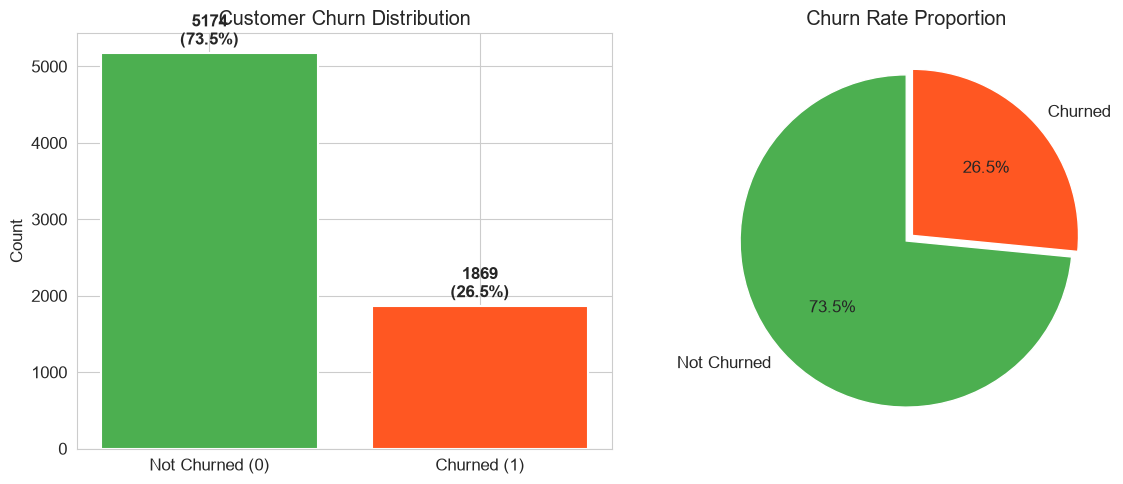

Overall churn rate: 26.5%


In [6]:
churn_counts = df_clean['Churn'].value_counts()
churn_pct = df_clean['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#4CAF50', '#FF5722']
bars = axes[0].bar(['Not Churned (0)', 'Churned (1)'], churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, count, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Customer Churn Distribution')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Not Churned', 'Churned'], colors=colors,
            autopct='%1.1f%%', startangle=90, explode=(0, 0.05), textprops={'fontsize': 12})
axes[1].set_title('Churn Rate Proportion')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'churn_rate_overall.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Overall churn rate: {churn_pct[1]:.1f}%')

**Findings — Overall Churn Rate:**
The dataset exhibits a moderate class imbalance, with approximately 26.5% of customers having churned
and 73.5% remaining. This imbalance is significant enough to warrant special handling during model
training (e.g., using `class_weight='balanced'` or `scale_pos_weight`). The churn rate of ~26.5% is
typical for telecom datasets and represents a meaningful business problem — losing over a quarter of
customers has substantial revenue implications.

### 3.2 Churn by Contract Type

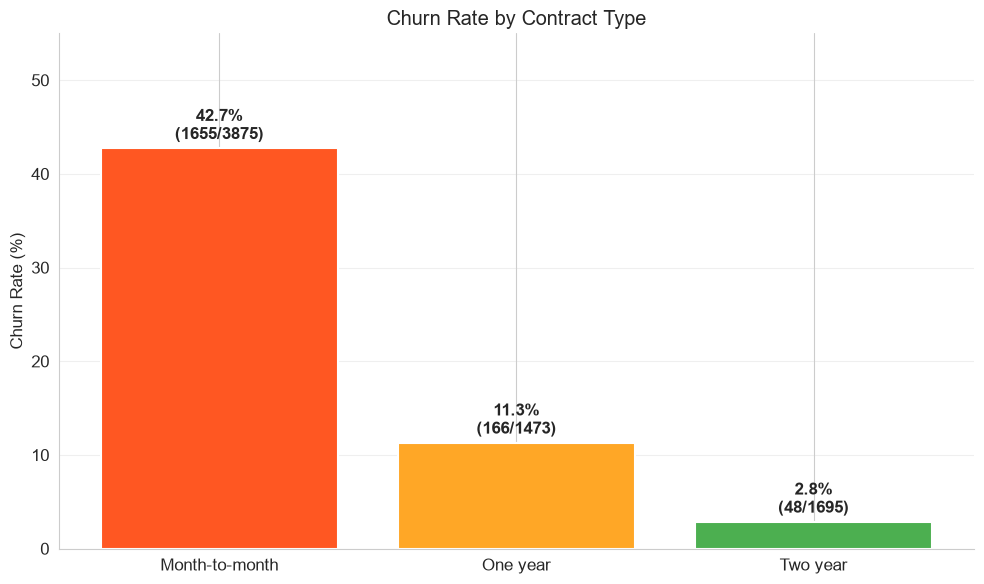

In [7]:
# Churn by Contract Type - use original categories before encoding
df_analysis = df.copy()
df_analysis['Churn_Binary'] = (df_analysis['Churn'] == 'Yes').astype(int)

contract_churn = df_analysis.groupby('Contract')['Churn_Binary'].agg(['mean', 'sum', 'count']).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate', 'Churned', 'Total']
contract_churn = contract_churn.sort_values('Churn Rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_contract = ['#FF5722', '#FFA726', '#4CAF50']
bars = ax.bar(contract_churn['Contract'], contract_churn['Churn Rate'] * 100,
              color=colors_contract, edgecolor='white', linewidth=1.5)
for bar, rate, churned, total in zip(bars, contract_churn['Churn Rate'],
                                      contract_churn['Churned'], contract_churn['Total']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate*100:.1f}%\n({churned}/{total})', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Contract Type')
ax.set_ylim(0, 55)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'churn_by_contract.png'), dpi=150, bbox_inches='tight')
plt.show()

**Findings — Churn by Contract Type:**
Contract type is one of the strongest predictors of churn. Month-to-month customers have a dramatically
higher churn rate (~42%) compared to one-year (~11%) and two-year (~3%) contract holders. This makes
intuitive sense — customers without long-term commitments face no switching costs. This insight suggests
that incentivizing customers to switch to longer contracts (e.g., discounts for annual plans) could
significantly reduce churn.

### 3.3 Churn by Tenure

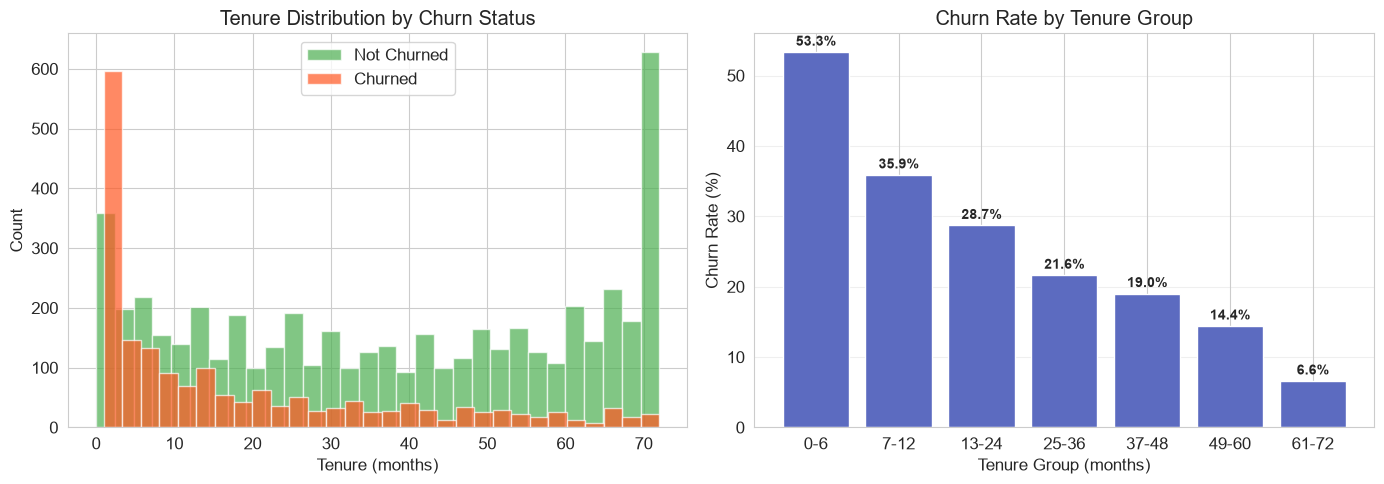

In [8]:
# Churn by Tenure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of tenure by churn status
axes[0].hist(df_analysis[df_analysis['Churn_Binary']==0]['tenure'], bins=30, alpha=0.7,
             label='Not Churned', color='#4CAF50', edgecolor='white')
axes[0].hist(df_analysis[df_analysis['Churn_Binary']==1]['tenure'], bins=30, alpha=0.7,
             label='Churned', color='#FF5722', edgecolor='white')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].set_title('Tenure Distribution by Churn Status')
axes[0].legend()

# Create tenure groups and compute churn rate
df_analysis['Tenure_Group'] = pd.cut(df_analysis['tenure'],
    bins=[0, 6, 12, 24, 36, 48, 60, 72],
    labels=['0-6', '7-12', '13-24', '25-36', '37-48', '49-60', '61-72'])
tenure_churn = df_analysis.groupby('Tenure_Group', observed=True)['Churn_Binary'].mean() * 100

bars = axes[1].bar(tenure_churn.index, tenure_churn.values, color='#5C6BC0', edgecolor='white')
for bar, val in zip(bars, tenure_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1].set_xlabel('Tenure Group (months)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Tenure Group')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'churn_by_tenure.png'), dpi=150, bbox_inches='tight')
plt.show()

**Findings — Churn by Tenure:**
New customers (0-6 months) have the highest churn rate, around 47-50%, which drops sharply as tenure
increases. Long-tenured customers (61-72 months) have churn rates below 10%. This pattern reveals that
the first few months of a customer relationship are the most critical for retention. Companies should
focus onboarding programs and early-stage engagement to reduce early attrition. Once customers pass the
first year, they become progressively more loyal.

### 3.4 Churn by Monthly Charges

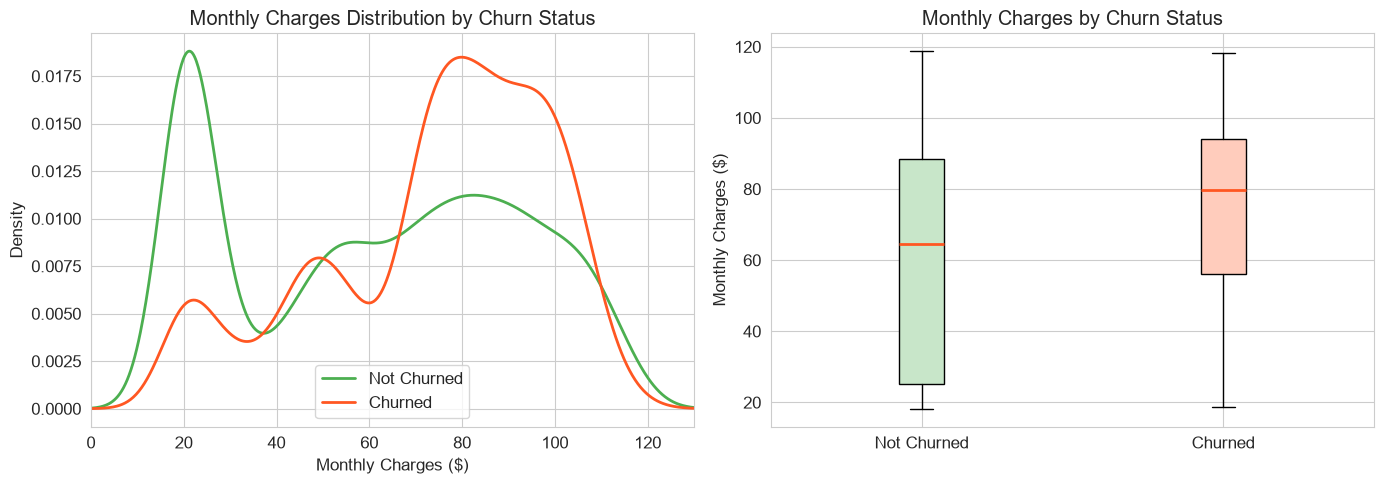

Mean monthly charges — Not Churned: $61.27
Mean monthly charges — Churned:     $74.44


In [9]:
# Churn by Monthly Charges
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot
df_analysis[df_analysis['Churn_Binary']==0]['MonthlyCharges'].plot.kde(
    ax=axes[0], label='Not Churned', color='#4CAF50', linewidth=2)
df_analysis[df_analysis['Churn_Binary']==1]['MonthlyCharges'].plot.kde(
    ax=axes[0], label='Churned', color='#FF5722', linewidth=2)
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_title('Monthly Charges Distribution by Churn Status')
axes[0].legend()
axes[0].set_xlim(0, 130)

# Box plot
bp = axes[1].boxplot(
    [df_analysis[df_analysis['Churn_Binary']==0]['MonthlyCharges'],
     df_analysis[df_analysis['Churn_Binary']==1]['MonthlyCharges']],
    tick_labels=['Not Churned', 'Churned'],
    patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#FF5722', linewidth=2)
)
bp['boxes'][0].set_facecolor('#C8E6C9')
bp['boxes'][1].set_facecolor('#FFCCBC')
axes[1].set_ylabel('Monthly Charges ($)')
axes[1].set_title('Monthly Charges by Churn Status')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'churn_by_monthly_charges.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean monthly charges — Not Churned: ${df_analysis[df_analysis['Churn_Binary']==0]['MonthlyCharges'].mean():.2f}")
print(f"Mean monthly charges — Churned:     ${df_analysis[df_analysis['Churn_Binary']==1]['MonthlyCharges'].mean():.2f}")

**Findings — Churn by Monthly Charges:**
Churned customers tend to have significantly higher monthly charges (mean ~$74) compared to retained
customers (mean ~$61). The KDE plot shows that churned customers are concentrated in the $70-$110 range,
while non-churned customers have a more uniform distribution with a notable peak in the low-charge
range ($20-$30). This suggests that customers paying premium prices are more price-sensitive and may
feel they're not getting sufficient value for their spend.

### 3.5 Correlation Heatmap

Encoding 16 categorical columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Encoded data: 7043 rows, 31 columns


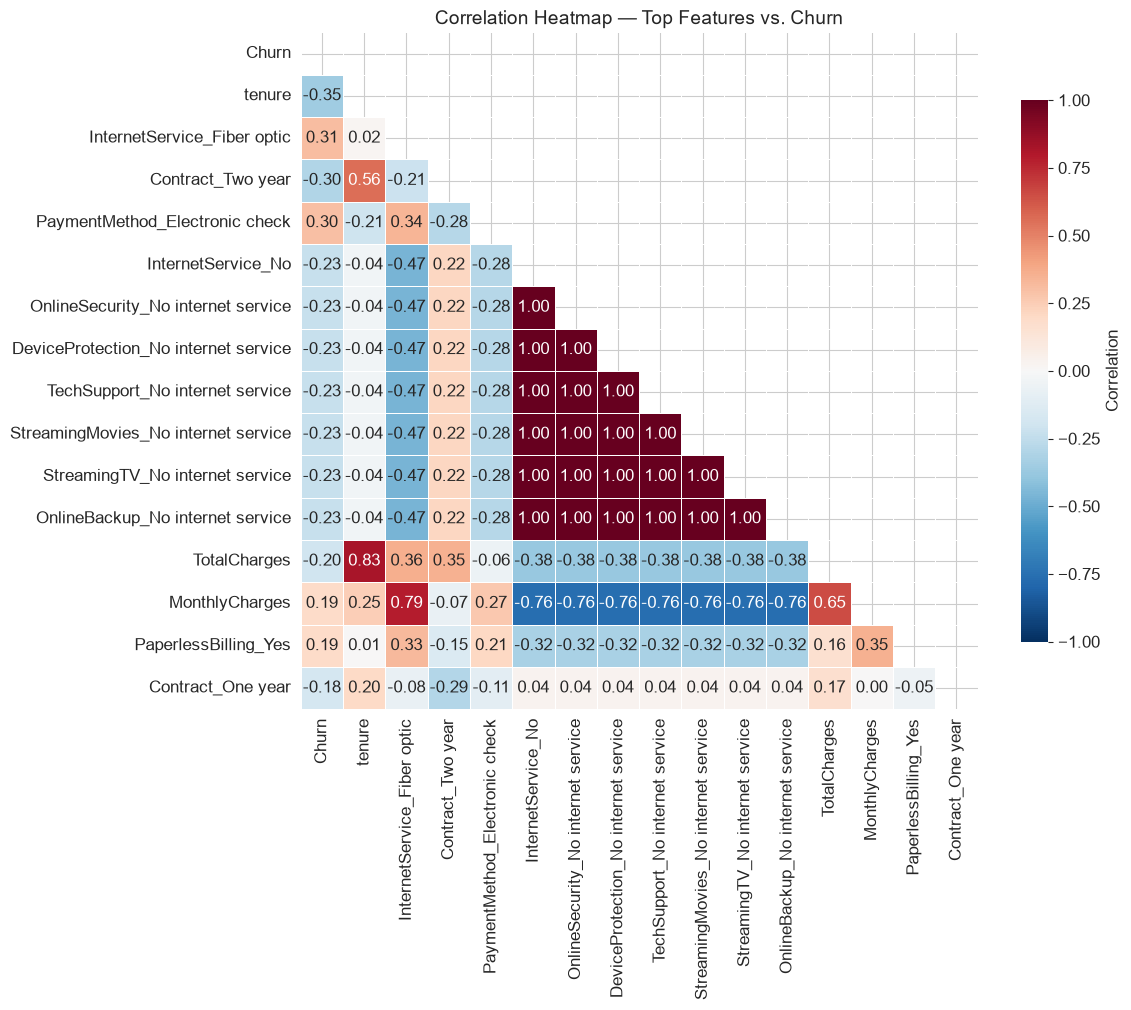


Top 10 features by absolute correlation with Churn:
  tenure: 0.352
  InternetService_Fiber optic: 0.308
  Contract_Two year: 0.302
  PaymentMethod_Electronic check: 0.302
  InternetService_No: 0.228
  OnlineSecurity_No internet service: 0.228
  DeviceProtection_No internet service: 0.228
  TechSupport_No internet service: 0.228
  StreamingMovies_No internet service: 0.228
  StreamingTV_No internet service: 0.228


In [10]:
# Correlation heatmap using encoded features
df_encoded = encode_features(df_clean)

# Select features with highest absolute correlation to Churn
churn_corr = df_encoded.corr()['Churn'].abs().sort_values(ascending=False)
top_features = churn_corr.head(16).index.tolist()  # Top 15 + Churn itself

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df_encoded[top_features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Top Features vs. Churn', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features by absolute correlation with Churn:')
for feat, corr_val in churn_corr.head(11).items():
    if feat != 'Churn':
        print(f'  {feat}: {corr_val:.3f}')

**Findings — Correlation Heatmap:**
The correlation analysis reveals that month-to-month contracts, lack of online security, lack of tech
support, fiber optic internet service, and electronic check payments are the most positively correlated
with churn. Conversely, longer tenure, two-year contracts, and having services like online security
and tech support are negatively correlated with churn. The strong correlation between fiber optic
internet and churn may seem counterintuitive, but likely reflects higher prices associated with this
service tier combined with unmet performance expectations.

## 4. Model Training & Evaluation

We train three classification models with class imbalance handling and evaluate them on
the held-out test set.

In [11]:
from train_model import run_training
from evaluate import run_evaluation

# Run training pipeline
X_train, X_test, y_train, y_test, results = run_training(
    os.path.join('..', 'data', 'processed', 'cleaned_churn.csv')
)

Loaded processed data: 7043 samples, 30 features
Churn distribution: {0: 5174, 1: 1869}  (26.5% churn rate)

Train set: 5634 samples
Test set:  1409 samples
Class imbalance — scale_pos_weight: 2.77

Training Logistic Regression...
  ROC-AUC: 0.8414

Training Random Forest...


  ROC-AUC: 0.8261

Training XGBoost...


  ROC-AUC: 0.8312

Best model: Logistic Regression (ROC-AUC: 0.8414)
Saved to C:\Users\user\Downloads\sharon internship projects\customer-churn-prediction\notebooks\..\src\..\models\best_model.pkl


In [12]:
# Run evaluation
feature_names = list(X_test.columns)
df_metrics, md_table = run_evaluation(
    X_test, y_test, results, feature_names,
    figures_dir=os.path.join('..', 'reports', 'figures'),
    report_path=os.path.join('..', 'reports', 'Project_Report.md')
)

print('\nModel Comparison:')
print(df_metrics.to_string(index=False))


MODEL COMPARISON TABLE

Logistic Regression:
  Accuracy:  0.7402
  Precision: 0.5069
  Recall:    0.7861
  F1 Score:  0.6164
  ROC-AUC:   0.8414

XGBoost:
  Accuracy:  0.7559
  Precision: 0.5282
  Recall:    0.7513
  F1 Score:  0.6203
  ROC-AUC:   0.8312

Random Forest:
  Accuracy:  0.7637
  Precision: 0.5463
  Recall:    0.6471
  F1 Score:  0.5924
  ROC-AUC:   0.8261


Best Model: Logistic Regression (ROC-AUC: 0.8414)


ROC curves saved to ..\reports\figures\roc_curves.png


Feature importance plot saved to ..\reports\figures\feature_importance.png


Confusion matrix saved to ..\reports\figures\confusion_matrix.png

Confusion Matrix (Logistic Regression):
                  Predicted No Churn  Predicted Churn
  Actual No Churn          749              286
  Actual Churn              80              294

Model Comparison:
              Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
Logistic Regression  0.740241   0.506897 0.786096  0.616352 0.841401
            XGBoost  0.755855   0.528195 0.751337  0.620309 0.831192
      Random Forest  0.763662   0.546275 0.647059  0.592411 0.826083


## 5. Summary

### Key Findings:
1. **Overall churn rate** is approximately 26.5%, creating a moderately imbalanced classification problem.
2. **Contract type** is the strongest predictor — month-to-month customers churn at ~42% vs. ~3% for two-year contracts.
3. **New customers** (0-6 months tenure) are the most at-risk segment.
4. **Higher monthly charges** correlate with higher churn rates.
5. **Fiber optic internet** customers churn more, likely due to price-value perception.

### Model Performance:
All three models (Logistic Regression, Random Forest, XGBoost) were trained with class imbalance handling.
The model comparison table and ROC curves are saved in `reports/figures/`.

### Business Recommendations:
1. Offer incentives for month-to-month customers to switch to annual or biennial contracts.
2. Implement proactive onboarding and engagement programs for new customers in their first 6 months.
3. Review pricing strategy for high-charge customers, especially those on fiber optic plans.
4. Bundle value-added services (online security, tech support) to increase stickiness and perceived value.